# Juego de Tronos - Análisis de la Estructura de la Red Social

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

%matplotlib inline

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [2]:
# Cargar el grafo desde el archivo GraphML
path = 'juegoDtronos.graphml'
G = nx.read_graphml(path)

print('Directed:', G.is_directed())
print('Nodes:', G.number_of_nodes())
print('Edges:', G.number_of_edges())
print('Weakly connected:', nx.is_weakly_connected(G))

# Para análisis social, trabajamos con la versión no dirigida
UG = G.to_undirected()
print('Undirected graph nodes:', UG.number_of_nodes())
print('Undirected graph edges:', UG.number_of_edges())

Directed: True
Nodes: 796
Edges: 5646
Weakly connected: True
Undirected graph nodes: 796
Undirected graph edges: 2823


In [3]:
# Diametro y longitud media de caminos
diameter = nx.diameter(UG)
avg_shortest_path = nx.average_shortest_path_length(UG)

print('Diámetro:', diameter)
print('Longitud media de caminos:', avg_shortest_path)

# Coeficiente de clustering
global_clustering = nx.transitivity(UG)
avg_clustering = nx.average_clustering(UG)
print('Coeficiente de clustering global (transitivity):', global_clustering)
print('Coeficiente de clustering medio:', avg_clustering)

Diámetro: 9
Longitud media de caminos: 3.416225783003066
Coeficiente de clustering global (transitivity): 0.2090366938564282
Coeficiente de clustering medio: 0.4858622073350483


Top 15 nodos por grado:
                    degree  local_clustering        degree_bin
Tyrion-Lannister       122          0.089283  (106.875, 122.0]
Jon-Snow               114          0.066294  (106.875, 122.0]
Jaime-Lannister        101          0.108515  (91.75, 106.875]
Cersei-Lannister        97          0.131658  (91.75, 106.875]
Stannis-Baratheon       89          0.106997   (76.625, 91.75]
Arya-Stark              84          0.112450   (76.625, 91.75]
Catelyn-Stark           75          0.138378    (61.5, 76.625]
Sansa-Stark             75          0.167568    (61.5, 76.625]
Eddard-Stark            74          0.151796    (61.5, 76.625]
Robb-Stark              74          0.141429    (61.5, 76.625]
Daenerys-Targaryen      73          0.076484    (61.5, 76.625]
Joffrey-Baratheon       69          0.219523    (61.5, 76.625]
Theon-Greyjoy           66          0.095105    (61.5, 76.625]
Robert-Baratheon        65          0.201923    (61.5, 76.625]
Bran-Stark              54     

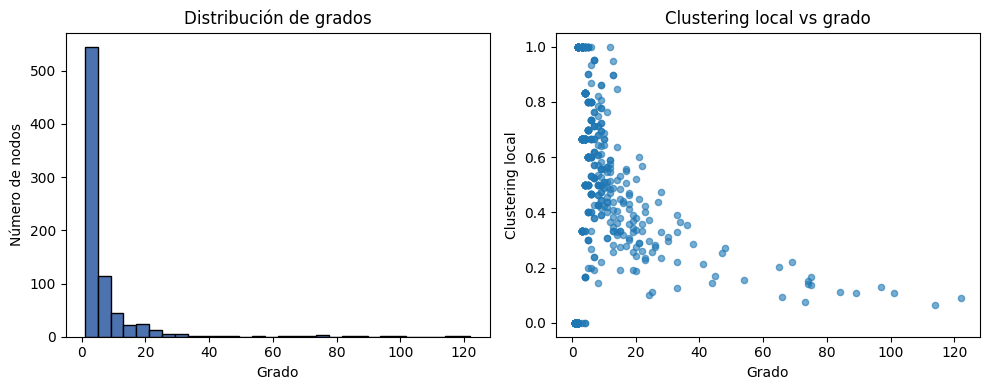

In [4]:
# Análisis de hubs y clustering local
degree_series = pd.Series(dict(UG.degree()))
clustering_series = pd.Series(nx.clustering(UG))

stats = pd.DataFrame({
    'degree': degree_series,
    'local_clustering': clustering_series
})
stats['degree_bin'] = pd.cut(stats['degree'], bins=8)

print('Top 15 nodos por grado:')
print(stats.sort_values('degree', ascending=False).head(15))

# Gráficas
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(stats['degree'], bins=30, color='#4C72B0', edgecolor='black')
plt.title('Distribución de grados')
plt.xlabel('Grado')
plt.ylabel('Número de nodos')

plt.subplot(1, 2, 2)
plt.scatter(stats['degree'], stats['local_clustering'], alpha=0.6, s=20)
plt.title('Clustering local vs grado')
plt.xlabel('Grado')
plt.ylabel('Clustering local')
plt.tight_layout()
plt.show()

## Comparación con redes sintéticas

Aquí comparamos las métricas de la red real con tres modelos sintéticos:
- Red aleatoria (Erdős–Rényi, mismo número de nodos y aristas)
- Red de mundo pequeño (Watts–Strogatz, grado promedio similar)
- Red de unión preferente (Barabási–Albert, crecimiento con preferencia)

                         n     m  connected  component_ratio
name                                                        
Aleatoria (ER)         796  2823       True              1.0
Mundo Pequeño (WS)     796  3184       True              1.0
Unión Preferente (BA)  796  3168       True              1.0
Red real               796  2823       True              1.0

                       diameter  avg_shortest_path  global_clustering  \
name                                                                    
Aleatoria (ER)                7           3.624999           0.007222   
Mundo Pequeño (WS)            9           4.867052           0.466947   
Unión Preferente (BA)         5           3.112032           0.028114   
Red real                      9           3.416226           0.209037   

                       avg_clustering  
name                                   
Aleatoria (ER)               0.006905  
Mundo Pequeño (WS)           0.478018  
Unión Preferente (BA)        0.039

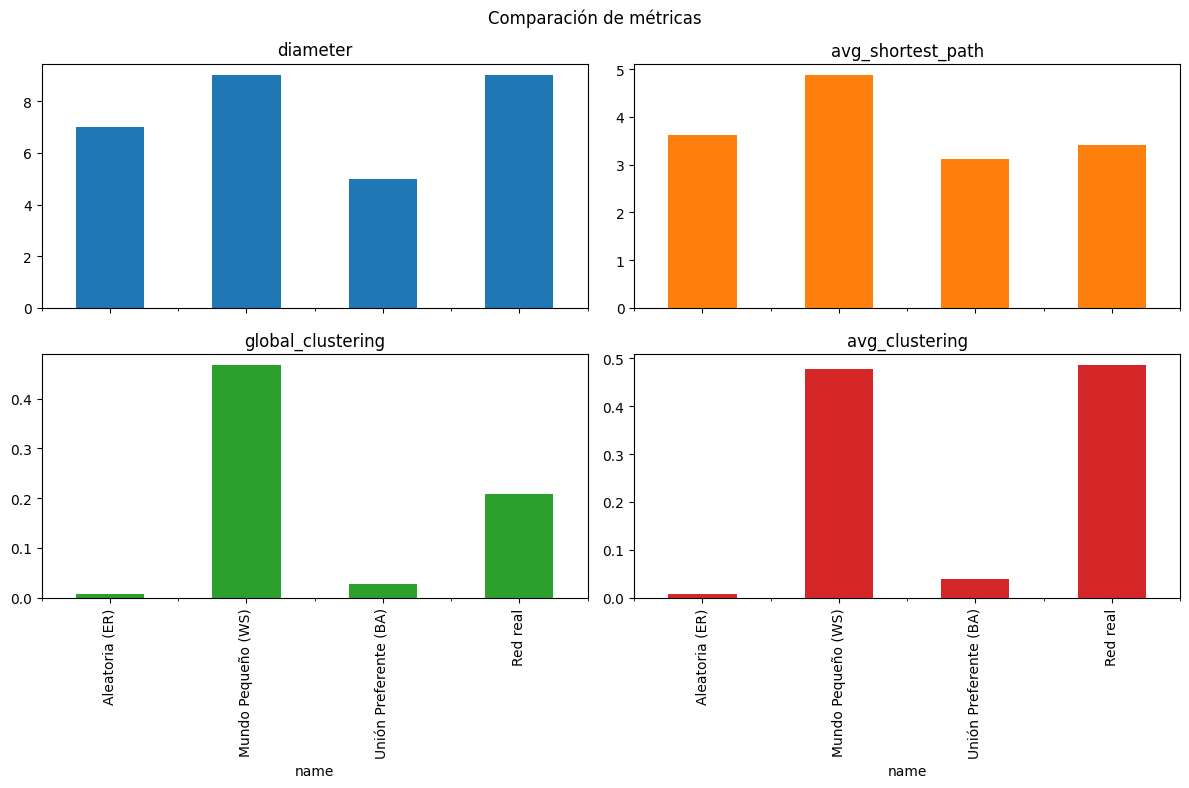

Average degree real: 7.092964824120603 WS k: 8 BA m: 4


In [5]:
def graph_stats(G, name=None, use_lcc=False):
    if use_lcc and not nx.is_connected(G):
        C = max(nx.connected_components(G), key=len)
        H = G.subgraph(C).copy()
    else:
        H = G
    return {
        'name': name,
        'n': H.number_of_nodes(),
        'm': H.number_of_edges(),
        'diameter': nx.diameter(H),
        'avg_shortest_path': nx.average_shortest_path_length(H),
        'global_clustering': nx.transitivity(H),
        'avg_clustering': nx.average_clustering(H),
        'connected': nx.is_connected(G),
        'component_ratio': len(H) / G.number_of_nodes()
    }

n = UG.number_of_nodes()
m = UG.number_of_edges()
avg_deg = 2 * m / n
k = int(round(avg_deg / 2) * 2)
p = 0.1
m_ba = max(1, int(round(avg_deg / 2)))

G_rand = nx.gnm_random_graph(n, m, seed=42)
G_ws = nx.watts_strogatz_graph(n, k=max(2, k), p=p, seed=42)
G_ba = nx.barabasi_albert_graph(n, m=m_ba, seed=42)

synthetic = [
    graph_stats(G_rand, name='Aleatoria (ER)', use_lcc=True),
    graph_stats(G_ws, name='Mundo Pequeño (WS)', use_lcc=True),
    graph_stats(G_ba, name='Unión Preferente (BA)', use_lcc=True),
    graph_stats(UG, name='Red real', use_lcc=False),
]
df_syn = pd.DataFrame(synthetic).set_index('name')
print(df_syn[['n','m','connected','component_ratio']])
print()
print(df_syn[['diameter','avg_shortest_path','global_clustering','avg_clustering']])
df_syn[['diameter','avg_shortest_path','global_clustering','avg_clustering']].plot(kind='bar', subplots=True, layout=(2,2), figsize=(12,8), legend=False, title='Comparación de métricas')
plt.tight_layout()
plt.show()

print('Average degree real:', avg_deg, 'WS k:', k, 'BA m:', m_ba)

## Conclusión mejorada

- La red real presenta un diámetro pequeño y una longitud media de caminos corta, más cercana al modelo de **mundo pequeño** que al aleatorio.
- Su coeficiente de clustering global es alto, lo cual es típico en redes sociales reales y consistente con redes de **mundo pequeño**.
- Sin embargo, la presencia de hubs con alto grado y clustering local relativamente bajo sugiere características de **unión preferente**.
- En conjunto, la red de Juego de Tronos combina rasgos de **mundo pequeño** y **unión preferente**, lo que es típico en muchas redes sociales reales.